# Colisión $pp \to \mu^{+}\mu^{-}$ para 10k eventos, 70,0 [GeV]

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import awkward as ak
import numpy as np
import uproot
import UpROOT.io as io
import UpROOT.config as conf
import UpROOT.physics.delphes as ph
import UpROOT.plotting.delphes as pt
import UpROOT.pipelines.delphes as pl
import UpROOT.fitting.delphes as fi
import UpROOT.delphes_root as dr

In [3]:
DATASET = 'mpmm_10k_70'

In [4]:
io.list_dataset_trees(
    dataset=DATASET
)


Archivo: MG5_pp_mpmm_10k_70GeV.root
Árboles encontrados (1):
1. Delphes


{WindowsPath('C:/Users/mario/Documents/PF/data/MG5_pp_mpmm_10k_70GeV.root'): ['Delphes']}

In [5]:
io.list_branches(
    dataset=DATASET,
    show_trees=True,
    show_branches=True,
    txt_path="mpmm_10k_70",
)

Árboles encontrados (1):
1. Delphes
Archivo: MG5_pp_mpmm_10k_70GeV.root
Árbol seleccionado: Delphes
Ramas encontradas: 455
 - EFlowNeutralHadron
 - EFlowNeutralHadron/EFlowNeutralHadron.E
 - EFlowNeutralHadron/EFlowNeutralHadron.ET
 - EFlowNeutralHadron/EFlowNeutralHadron.Edges[4]
 - EFlowNeutralHadron/EFlowNeutralHadron.Eem
 - EFlowNeutralHadron/EFlowNeutralHadron.Ehad
 - EFlowNeutralHadron/EFlowNeutralHadron.Eta
 - EFlowNeutralHadron/EFlowNeutralHadron.Etrk
 - EFlowNeutralHadron/EFlowNeutralHadron.HardEnergyFraction
 - EFlowNeutralHadron/EFlowNeutralHadron.IsPU
 - EFlowNeutralHadron/EFlowNeutralHadron.IsRecoPU
 - EFlowNeutralHadron/EFlowNeutralHadron.NTimeHits
 - EFlowNeutralHadron/EFlowNeutralHadron.Particles
 - EFlowNeutralHadron/EFlowNeutralHadron.Phi
 - EFlowNeutralHadron/EFlowNeutralHadron.T
 - EFlowNeutralHadron/EFlowNeutralHadron.X
 - EFlowNeutralHadron/EFlowNeutralHadron.Y
 - EFlowNeutralHadron/EFlowNeutralHadron.Z
 - EFlowNeutralHadron/EFlowNeutralHadron.fBits
 - EFlowNeutra

['EFlowNeutralHadron',
 'EFlowNeutralHadron/EFlowNeutralHadron.E',
 'EFlowNeutralHadron/EFlowNeutralHadron.ET',
 'EFlowNeutralHadron/EFlowNeutralHadron.Edges[4]',
 'EFlowNeutralHadron/EFlowNeutralHadron.Eem',
 'EFlowNeutralHadron/EFlowNeutralHadron.Ehad',
 'EFlowNeutralHadron/EFlowNeutralHadron.Eta',
 'EFlowNeutralHadron/EFlowNeutralHadron.Etrk',
 'EFlowNeutralHadron/EFlowNeutralHadron.HardEnergyFraction',
 'EFlowNeutralHadron/EFlowNeutralHadron.IsPU',
 'EFlowNeutralHadron/EFlowNeutralHadron.IsRecoPU',
 'EFlowNeutralHadron/EFlowNeutralHadron.NTimeHits',
 'EFlowNeutralHadron/EFlowNeutralHadron.Particles',
 'EFlowNeutralHadron/EFlowNeutralHadron.Phi',
 'EFlowNeutralHadron/EFlowNeutralHadron.T',
 'EFlowNeutralHadron/EFlowNeutralHadron.X',
 'EFlowNeutralHadron/EFlowNeutralHadron.Y',
 'EFlowNeutralHadron/EFlowNeutralHadron.Z',
 'EFlowNeutralHadron/EFlowNeutralHadron.fBits',
 'EFlowNeutralHadron/EFlowNeutralHadron.fUniqueID',
 'EFlowNeutralHadron_size',
 'EFlowPhoton',
 'EFlowPhoton/EFlowPho

In [6]:
io.load_dataframe(
    branches=io.txt_data("mpmm"),
    dataset=DATASET,
).head()

Ramas cargadas desde: C:\Users\mario\Documents\PF\MadGraph\analysis\mpmm.txt
Cantidad de ramas: 33
Archivo: MG5_pp_mpmm_10k_70GeV.root
Árbol seleccionado: Delphes
Total de eventos: 10,000 eventos


,Event/Event.CrossSection,Event/Event.CrossSectionError,Event/Event.Number,Event/Event.Weight,Jet/Jet.BTag,Jet/Jet.Charge,Jet/Jet.ChargedEnergyFraction,Jet/Jet.Constituents,Jet/Jet.Eta,Jet/Jet.Mass,...,Muon/Muon.IsolationVarRhoCorr,Muon/Muon.PT,Muon/Muon.Particle,Muon/Muon.Phi,Muon/Muon.SumPt,Muon/Muon.SumPtCharged,Muon/Muon.SumPtChargedPU,Muon/Muon.SumPtNeutral,Muon/Muon.T,Muon_size
0,[0.08072508126497269],[201.8126983642578],[0],[155.5768280029297],[],[],[],[],[],[],...,"[0.19049347937107086, 0.0]","[16.711992263793945, 12.250988006591797]","[{'ref': 243}, {'ref': 242}]","[2.4322478771209717, -0.7494567632675171]","[3.183525800704956, 0.0]","[0.766453742980957, 0.0]","[0.0, 0.0]","[2.417072057723999, 0.0]","[7.3388592980450085e-09, 1.0585646137428739e-08]",2
1,[0.16145016252994537],[0.0],[1],[147.5939178466797],[],[],[],[],[],[],...,[0.1660616546869278],[10.45939826965332],[{'ref': 479}],[-2.623570203781128],[1.7369049787521362],[1.7369049787521362],[0.0],[0.0],[4.512807016965326e-09],1
2,[0.24217523634433746],[0.0],[2],[152.50167846679688],[],[],[],[],[],[],...,[0.052140988409519196],[23.5063533782959],[{'ref': 495}],[1.9122341871261597],[1.2256444692611694],[1.2256444692611694],[0.0],[0.0],[4.510036344385071e-09],1
3,[0.32290032505989075],[0.0],[3],[160.1951446533203],[],[],[],[],[],[],...,[0.0],[25.581783294677734],[{'ref': 691}],[-1.5329649448394775],[0.0],[0.0],[0.0],[0.0],[4.7615573706139e-09],1
4,[0.40362539887428284],[0.0],[4],[154.64279174804688],[0],[-1],[0.34815216064453125],"[{'fName': '', 'fSize': 9, 'refs': [3073, 3071...",[1.6216026544570923],[6.625208377838135],...,[0.055559106171131134],[17.196043014526367],[{'ref': 647}],[-1.8264185190200806],[0.9553967714309692],[0.9553967714309692],[0.0],[0.0],[4.306817569244004e-09],1


In [7]:
aw = io.load_awkward(
    branches=io.txt_data("mpmm"),
    dataset=DATASET,
    simplify_names=True
)

Ramas cargadas desde: C:\Users\mario\Documents\PF\MadGraph\analysis\mpmm.txt
Cantidad de ramas: 33
Archivo: MG5_pp_mpmm_10k_70GeV.root
Árbol seleccionado: Delphes
Total de evenots: 10,000 eventos


In [8]:
aw[:100]

<Array [{'Event.CrossSection': ..., ...}, ...] type='100 * {"Event.CrossSec...'>

In [9]:
print(aw.fields)

['Event.CrossSection', 'Event.CrossSectionError', 'Event.Number', 'Event.Weight', 'Jet.BTag', 'Jet.Charge', 'Jet.ChargedEnergyFraction', 'Jet.Constituents', 'Jet.Eta', 'Jet.Mass', 'Jet.PT', 'Jet.Phi', 'Jet_size', 'MissingET.Eta', 'MissingET.MET', 'MissingET.Phi', 'Muon.Charge', 'Muon.D0', 'Muon.DZ', 'Muon.ErrorD0', 'Muon.ErrorDZ', 'Muon.Eta', 'Muon.IsolationVar', 'Muon.IsolationVarRhoCorr', 'Muon.PT', 'Muon.Particle', 'Muon.Phi', 'Muon.SumPt', 'Muon.SumPtCharged', 'Muon.SumPtChargedPU', 'Muon.SumPtNeutral', 'Muon.T', 'Muon_size']


In [10]:
branch_size = sorted(
    [(field, aw[field].nbytes/1024**2) for field in aw.fields],
    key=lambda item: item[1], reverse=True
)
for field, size_mb in branch_size[:60]:
    print(f"{field:35s}{size_mb:10.2f} MB")
print(f"Eventos{len(aw):,}")
print(f"Memoria total: {aw.nbytes/1024**2:.2f} MB")

Jet.Constituents                         0.21 MB
Event.Number                             0.15 MB
Muon.Charge                              0.13 MB
Muon.D0                                  0.13 MB
Muon.DZ                                  0.13 MB
Muon.ErrorD0                             0.13 MB
Muon.ErrorDZ                             0.13 MB
Muon.Eta                                 0.13 MB
Muon.IsolationVar                        0.13 MB
Muon.IsolationVarRhoCorr                 0.13 MB
Muon.PT                                  0.13 MB
Muon.Particle                            0.13 MB
Muon.Phi                                 0.13 MB
Muon.SumPt                               0.13 MB
Muon.SumPtCharged                        0.13 MB
Muon.SumPtChargedPU                      0.13 MB
Muon.SumPtNeutral                        0.13 MB
Muon.T                                   0.13 MB
Event.CrossSection                       0.11 MB
Event.CrossSectionError                  0.11 MB
Event.Weight        

In [11]:
io.load_dataframe(
    branches=io.txt_data("prueba"),
    dataset=DATASET,
).head(9)

Ramas cargadas desde: C:\Users\mario\Documents\PF\MadGraph\analysis\prueba.txt
Cantidad de ramas: 11
Archivo: MG5_pp_mpmm_10k_70GeV.root
Árbol seleccionado: Delphes
Total de eventos: 10,000 eventos


,FatJet/FatJet.fUniqueID,Jet/Jet.Constituents,Jet/Jet.PTD,Jet/Jet.Particles,Jet/Jet.fUniqueID,Muon/Muon.PT,Muon/Muon.Particle,Muon/Muon.fUniqueID,Particle/Particle.PID,Particle/Particle.PT,Particle/Particle.fUniqueID
0,[],[],[],[],[],"[16.711992263793945, 12.250988006591797]","[{'ref': 243}, {'ref': 242}]","[1414, 1413]","[-2, 2, -13, 13, 21, 21, 21, 21, 21, 21, 21, 2...","[0.0, 0.0, 14.095187187194824, 14.095187187194...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
1,[],[],[],[],[],[10.45939826965332],[{'ref': 479}],[1611],"[-2, 21, 2, -13, 13, 21, 1, 21, 21, 1, 2, 21, ...","[0.0, 1.2935198545455933, 0.0, 10.139117240905...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
2,[],[],[],[],[],[23.5063533782959],[{'ref': 495}],[2154],"[2, -2, 2, -13, 13, 2, -2, 21, -13, 13, 21, 21...","[0.0, 0.0, 16.610143661499023, 12.065213203430...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
3,[],[],[],[],[],[25.581783294677734],[{'ref': 691}],[2361],"[2, 21, -2, -13, 13, 2, 21, -2, -13, 13, 2, -2...","[0.0, 15.728705406188965, 0.0, 17.757450103759...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
4,[],"[{'fName': '', 'fSize': 9, 'refs': [3073, 3071...",[0.0],"[{'fName': '', 'fSize': 8, 'refs': [940, 979, ...",[0],[17.196043014526367],[{'ref': 647}],[2548],"[-1, 1, 21, -13, 13, -1, 21, 1, -13, 13, 21, 2...","[0.0, 0.0, 5.646731853485107, 12.0738954544067...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
5,[],"[{'fName': '', 'fSize': 6, 'refs': [990, 979, ...",[0.0],"[{'fName': '', 'fSize': 9, 'refs': [231, 232, ...",[0],[12.482503890991211],[{'ref': 161}],[787],"[2, -2, 2, -13, 13, 21, 21, 21, 21, 21, 21, 21...","[0.0, 0.0, 4.284790992736816, 13.8666601181030...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
6,[],[],[],[],[],"[16.926082611083984, 16.473886489868164]","[{'ref': 387}, {'ref': 388}]","[1618, 1619]","[4, -4, 4, -13, 13, 21, 21, -2, 21, 21, 21, 21...","[0.0, 0.0, 3.838502883911133, 16.6844711303710...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
7,[],[],[],[],[],"[16.307401657104492, 14.313549995422363]","[{'ref': 148}, {'ref': 147}]","[638, 637]","[-4, 4, -4, -13, 13, -4, 21, 21, -13, 13, -4, ...","[0.0, 0.0, 10.320813179016113, 15.480232238769...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
8,[],"[{'fName': '', 'fSize': 7, 'refs': [3319, 3311...",[0.0],"[{'fName': '', 'fSize': 6, 'refs': [703, 1180,...",[0],[10.662861824035645],[{'ref': 704}],[2775],"[-2, 21, 2, -13, 13, 2, -2, 21, 2, 21, 21, 21,...","[0.0, 4.230671405792236, 0.0, 14.0471487045288...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."


In [12]:
io.load_dataframe(
    branches=io.txt_data("prueba02"),
    dataset=DATASET,
).head(10)

Ramas cargadas desde: C:\Users\mario\Documents\PF\MadGraph\analysis\prueba02.txt
Cantidad de ramas: 15
Archivo: MG5_pp_mpmm_10k_70GeV.root
Árbol seleccionado: Delphes
Total de eventos: 10,000 eventos


,EFlowNeutralHadron/EFlowNeutralHadron.Particles,EFlowNeutralHadron/EFlowNeutralHadron.fUniqueID,EFlowPhoton/EFlowPhoton.Particles,EFlowPhoton/EFlowPhoton.fUniqueID,EFlowTrack/EFlowTrack.Particle,EFlowTrack/EFlowTrack.fUniqueID,GenJet/GenJet.Particles,GenJet/GenJet.fUniqueID,GenMissingET/GenMissingET.fUniqueID,MissingET/MissingET.fUniqueID,Tower/Tower.Particles,Tower/Tower.fUniqueID,Track/Track.Particle,Track/Track.fUniqueID,Weight/Weight.fUniqueID
0,"[{'fName': '', 'fSize': 2, 'refs': [543, 644]}...","[1605, 1607, 1610, 1613, 1616, 1622, 1625, 163...","[{'fName': '', 'fSize': 1, 'refs': [823]}, {'f...","[1418, 1443, 1457, 1471, 1473, 1512, 1533, 153...","[{'ref': 659}, {'ref': 566}, {'ref': 657}, {'r...","[1680, 1684, 1687, 1692, 1694, 1697, 1700, 170...",[],[],[0],[0],"[{'fName': '', 'fSize': 1, 'refs': [823]}, {'f...","[1417, 1442, 1456, 1470, 1472, 1511, 1532, 153...","[{'ref': 322}, {'ref': 338}, {'ref': 350}, {'r...","[1391, 1392, 1393, 1394, 1395, 1396, 1397, 139...",[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...
1,"[{'fName': '', 'fSize': 1, 'refs': [899]}, {'f...","[1785, 1787, 1791, 1793, 1795, 1798, 1800, 180...","[{'fName': '', 'fSize': 1, 'refs': [1114]}, {'...","[1620, 1622, 1652, 1687, 1718, 1734, 1741, 175...","[{'ref': 1127}, {'ref': 748}, {'ref': 1058}, {...","[1837, 1839, 1841, 1847, 1852, 1612, 1611, 186...",[],[],[0],[0],"[{'fName': '', 'fSize': 1, 'refs': [1114]}, {'...","[1619, 1621, 1651, 1686, 1717, 1733, 1740, 174...","[{'ref': 748}, {'ref': 795}, {'ref': 834}, {'r...","[1595, 1596, 1597, 1598, 1599, 1600, 1601, 160...",[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...
2,"[{'fName': '', 'fSize': 1, 'refs': [1127]}, {'...","[2442, 2444, 2446, 2448, 2450, 2453, 2457, 246...","[{'fName': '', 'fSize': 1, 'refs': [1414]}, {'...","[2159, 2161, 2164, 2169, 2171, 2174, 2177, 218...","[{'ref': 1180}, {'ref': 921}, {'ref': 1002}, {...","[2567, 2569, 2571, 2573, 2575, 2578, 2583, 258...","[{'fName': '', 'fSize': 12, 'refs': [495, 512,...","[0, 0, 0]",[0],[0],"[{'fName': '', 'fSize': 1, 'refs': [1414]}, {'...","[2158, 2160, 2163, 2168, 2170, 2173, 2176, 218...","[{'ref': 657}, {'ref': 673}, {'ref': 705}, {'r...","[2111, 2112, 2113, 2114, 2115, 2116, 2117, 211...",[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...
3,"[{'fName': '', 'fSize': 1, 'refs': [1536]}, {'...","[2609, 2611, 2615, 2617, 2620, 2622, 2624, 262...","[{'fName': '', 'fSize': 1, 'refs': [1652]}, {'...","[2368, 2409, 2411, 2432, 2444, 2462, 2467, 250...","[{'ref': 1398}, {'ref': 1175}, {'ref': 1599}, ...","[2704, 2707, 2709, 2711, 2713, 2716, 2721, 272...","[{'fName': '', 'fSize': 9, 'refs': [691, 704, ...",[0],[0],[0],"[{'fName': '', 'fSize': 1, 'refs': [1652]}, {'...","[2367, 2408, 2410, 2431, 2443, 2461, 2466, 250...","[{'ref': 926}, {'ref': 930}, {'ref': 939}, {'r...","[2313, 2314, 2315, 2316, 2317, 2318, 2319, 232...",[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...
4,"[{'fName': '', 'fSize': 1, 'refs': [873]}, {'f...","[2887, 2889, 2891, 2893, 2895, 2898, 2900, 290...","[{'fName': '', 'fSize': 1, 'refs': [1656]}, {'...","[2555, 2558, 2561, 2571, 2584, 2591, 2597, 262...","[{'ref': 1004}, {'ref': 1012}, {'ref': 999}, {...","[2985, 2988, 2989, 2995, 2997, 2999, 3000, 300...",[],[],[0],[0],"[{'fName': '', 'fSize': 1, 'refs': [1656]}, {'...","[2554, 2557, 2560, 2570, 2583, 2590, 2596, 262...","[{'ref': 877}, {'ref': 939}, {'ref': 979}, {'r...","[2484, 2485, 2486, 2487, 2488, 2489, 2490, 249...",[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...
5,"[{'fName': '', 'fSize': 1, 'refs': [414]}, {'f...","[892, 895, 899, 901, 908, 910, 913, 919, 933, ...","[{'fName': '', 'fSize': 1, 'refs': [428]}, {'f...","[809, 830, 864, 875]","[{'ref': 404}, {'ref': 394}, {'ref': 392}, {'r...","[921, 923, 925, 929, 931, 935, 937, 939, 941, ...","[{'fName': '', 'fSize': 13, 'refs': [231, 232,...",[0],[0],[0],"[{'fName': '', 'fSize': 1, 'refs': [428]}, {'f...","[808, 829, 863, 874, 891, 894, 898, 900, 907, ...","[{'ref': 224}, {'ref': 227}, {'ref': 271}, {'r...","[76

In [13]:
io.load_dataframe(
    branches=io.txt_data("particle"),
    dataset=DATASET,
).head()

Ramas cargadas desde: C:\Users\mario\Documents\PF\MadGraph\analysis\particle.txt
Cantidad de ramas: 4
Archivo: MG5_pp_mpmm_10k_70GeV.root
Árbol seleccionado: Delphes
Total de eventos: 10,000 eventos


,Particle/Particle.D1,Particle/Particle.D2,Particle/Particle.M1,Particle/Particle.M2
0,"[2, 2, 241, 242, 7, 7, 41, 37, 38, 12, 23, 12,...","[3, 3, 241, 242, 8, 8, 41, 37, 38, 13, 23, 13,...","[214, 228, 0, 0, 34, 35, 35, 4, 4, 14, 14, 15,...","[-1, -1, 1, 1, -1, -1, -1, 5, 5, -1, -1, -1, 1..."
1,"[3, 172, 3, 138, 139, 8, 8, 130, 46, 47, 13, 1...","[4, 172, 4, 138, 139, 9, 9, 130, 46, 47, 14, 1...","[135, 135, 137, 0, 0, 43, 45, 45, 5, 5, 58, 59...","[-1, -1, -1, 2, 2, -1, -1, -1, 6, 6, -1, -1, -..."
2,"[3, 3, 15, 8, 9, 0, 32, 1, 13, 14, 5, 7, 193, ...","[4, 4, 15, 8, 9, 0, 32, 2, 13, 14, 6, 7, 193, ...","[5, 7, 7, 0, 0, 10, 10, 11, 3, 4, 26, 27, 27, ...","[-1, -1, -1, 1, 1, -1, -1, -1, -1, -1, -1, -1,..."
3,"[3, 14, 3, 8, 9, 0, 202, 2, 12, 13, 5, 7, 544,...","[4, 14, 4, 8, 9, 1, 202, 2, 12, 13, 6, 7, 544,...","[5, 5, 7, 0, 0, 10, 10, 11, 3, 4, 655, 99, 8, ...","[-1, -1, -1, 2, 2, -1, -1, -1, -1, -1, -1, -1,..."
4,"[3, 3, 29, 8, 9, 0, 396, 1, 27, 28, 13, 154, 1...","[4, 4, 29, 8, 9, 0, 396, 2, 27, 28, 14, 154, 1...","[5, 7, 7, 0, 0, 25, 25, 26, 3, 4, 101, 101, 10...","[-1, -1, -1, 1, 1, -1, -1, -1, -1, -1, -1, -1,..."


In [ ]:
output = dr.convert_dataset(
    dataset=DATASET,
    collections=('Electron', 'Event', 'Jet', 'Muon', 'Particle', 'Photon', 'ScalarHT', 'Weight'),
    step_size='20 MB',
    object_registry=True,
    overwrite=True
)

Ramas internas de ROOT excluidas:
 - EFlowNeutralHadron/EFlowNeutralHadron.fBits
 - EFlowPhoton/EFlowPhoton.fBits
 - EFlowTrack/EFlowTrack.fBits
 - Electron/Electron.fBits
 - Event/Event.fBits
 - FatJet/FatJet.fBits
 - GenJet/GenJet.fBits
 - GenMissingET/GenMissingET.fBits
 - Jet/Jet.fBits
 - MissingET/MissingET.fBits
 - Muon/Muon.fBits
 - Particle/Particle.fBits
 - Photon/Photon.fBits
 - ScalarHT/ScalarHT.fBits
 - Tower/Tower.fBits
 - Track/Track.fBits
 - Weight/Weight.fBits

Archivo de entrada: C:\Users\mario\Documents\PF\data\MG5_pp_mpmm_10k_70GeV.root
Eventos: 10,000
Colecciones: Electron, Jet, Muon, Particle, Photon, ScalarHT, Weight
 Electrons: 18 ramas; bloques de 20 MB
 Jets: 46 ramas; bloques de 20 MB
 Muons: 17 ramas; bloques de 20 MB
 Particles: 23 ramas; bloques de 20 MB
 Photons: 15 ramas; bloques de 20 MB
 ScalarHT: 2 ramas; bloques de 20 MB
 Weights: 2 ramas; bloques de 20 MB

ROOT tabular creado: C:\Users\mario\Documents\PF\data\mpmm_10k_70_pandas.root
Árboles generados

In [15]:
dset = 'mpmm_10k_70_p'
df_events = io.load_dataframe(
    branches=None,
    dataset=dset,
    tree_path='Events'
)
df_events.head()

Archivo: mpmm_10k_70_pandas.root
Árbol seleccionado: Events
Total de eventos: 10,000 eventos


,source_file_id,event_id,source_entry,root_uid,event_number,ReadTime,ProcTime,ProcessID,MPI,event_weight,...,ScalePDF,PDF1,PDF2,n_Electron,n_Jet,n_Muon,n_Particle,n_Photon,n_ScalarHT,n_Weight
0,0,0,0,0,0,0.332367,0.012099,9999,-1,155.576828,...,0.0,0.0,0.0,0,0,2,997,0,1,292
1,0,1,1,0,1,0.008470,0.005705,9999,-1,147.593918,...,0.0,0.0,0.0,0,0,1,1238,0,1,292
2,0,2,2,0,2,0.010686,0.016189,9999,-1,152.501678,...,0.0,0.0,0.0,0,0,1,1560,0,1,292
3,0,3,3,0,3,0.007572,0.004560,9999,-1,160.195145,...,0.0,0.0,0.0,0,0,1,1807,0,1,292
4,0,4,4,0,4,0.005888,0.004310,9999,-1,154.642792,...,0.0,0.0,0.0,0,1,1,1893,0,1,292


In [16]:
df_events.shape

(10000, 29)

In [17]:
df_events.columns.to_list()

['source_file_id',
 'event_id',
 'source_entry',
 'root_uid',
 'event_number',
 'ReadTime',
 'ProcTime',
 'ProcessID',
 'MPI',
 'event_weight',
 'CrossSection',
 'CrossSectionError',
 'Scale',
 'AlphaQED',
 'AlphaQCD',
 'ID1',
 'ID2',
 'X1',
 'X2',
 'ScalePDF',
 'PDF1',
 'PDF2',
 'n_Electron',
 'n_Jet',
 'n_Muon',
 'n_Particle',
 'n_Photon',
 'n_ScalarHT',
 'n_Weight']

In [18]:
df_muons = io.load_dataframe(
    branches=None,
    dataset=dset,
    tree_path='Muons'
)
df_muons.head(7)

Archivo: mpmm_10k_70_pandas.root
Árbol seleccionado: Muons
Total de eventos: 13,533 eventos


,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Charge,...,IsolationVar,IsolationVarRhoCorr,SumPtCharged,SumPtNeutral,SumPtChargedPU,SumPt,D0,DZ,ErrorD0,ErrorDZ
0,0,0,0,0,1414,16.711992,1.126818,2.432248,7.338859e-09,-1,...,0.190493,0.190493,0.766454,2.417072,0.0,3.183526,0.0,0.0,0.0,0.0
1,0,0,0,1,1413,12.250988,1.785965,-0.749457,1.058565e-08,1,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,-0.0,0.0,0.0,0.0
2,0,1,1,0,1611,10.459398,0.308113,-2.623570,4.512807e-09,1,...,0.166062,0.166062,1.736905,0.000000,0.0,1.736905,0.0,0.0,0.0,0.0
3,0,2,2,0,2154,23.506353,-0.308431,1.912234,4.510036e-09,-1,...,0.052141,0.052141,1.225644,0.000000,0.0,1.225644,0.0,0.0,0.0,0.0
4,0,3,3,0,2361,25.581783,0.457336,-1.532965,4.761557e-09,1,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,-0.0,0.0,0.0,0.0
5,0,4,4,0,2548,17.196043,-0.033409,-1.826419,4.306818e-09,1,...,0.055559,0.055559,0.955397,0.000000,0.0,0.955397,0.0,0.0,0.0,0.0
6,0,5,5,0,787,12.482504,1.849157,-2.474256,1.051519e-08,-1,...,0.175184,0.175184,0.753734,1.432998,0.0,2.186733,0.0,0.0,0.0,0.0


In [19]:
print(f"Eventos: {len(df_events):,}")
print(f"Muones: {len(df_muons):,}")
print(f"Eventos con muones: {df_muons["event_id"].nunique():,}")
print(f"Carga de los muones")
print(df_muons["Charge"].value_counts().sort_index())

Eventos: 10,000
Muones: 13,533
Eventos con muones: 8,975
Carga de los muones
Charge
-1    6762
 1    6771
Name: count, dtype: int64


In [20]:
df_events[["event_id", "n_Muon"]].head(10)

,event_id,n_Muon
0,0,2
1,1,1
2,2,1
3,3,1
4,4,1
5,5,1
6,6,2
7,7,2
8,8,1
9,9,2


In [21]:
muon_counts = (df_muons.groupby("event_id").size())
muon_counts.describe()

count    8975.000000
mean        1.507855
std         0.499966
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         2.000000
dtype: float64

Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c01\delphes_event_multiplicities.png.


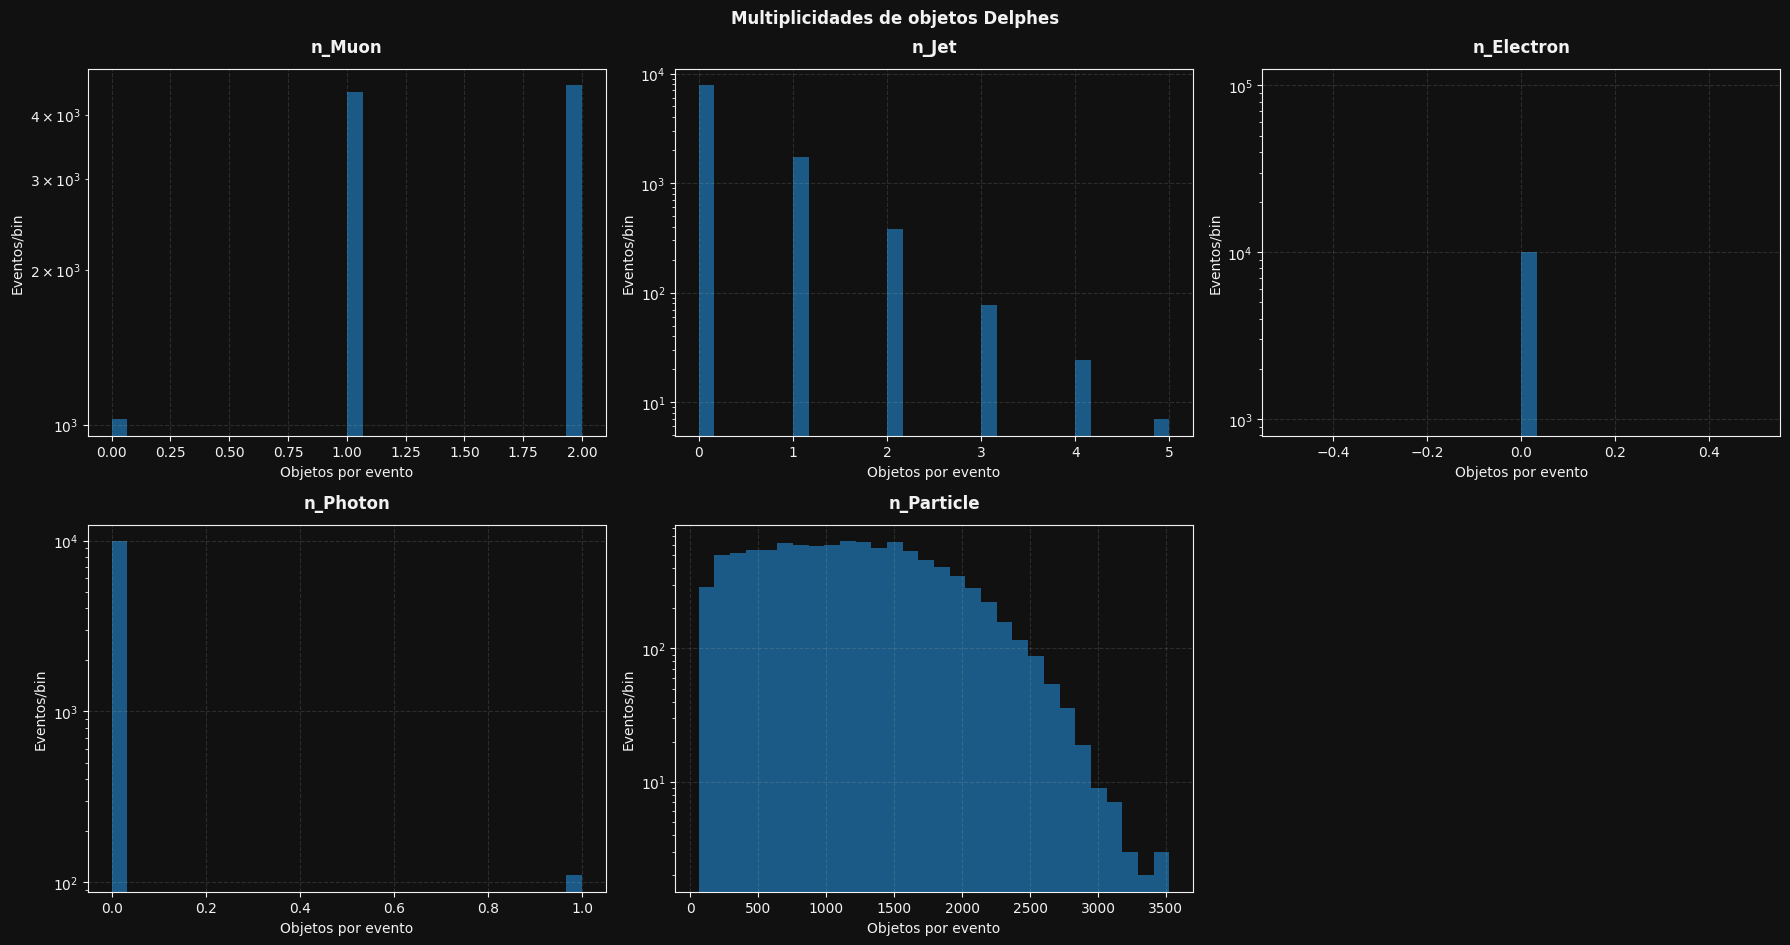

(<Figure size 1800x960 with 6 Axes>,
 array([[<Axes: title={'center': 'n_Muon'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'n_Jet'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'n_Electron'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>],
        [<Axes: title={'center': 'n_Photon'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'n_Particle'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: >]], dtype=object))

In [22]:
pt.plot_event_multiplicities(df_events, save=True)

c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c01\muon_kinematics_01.png.


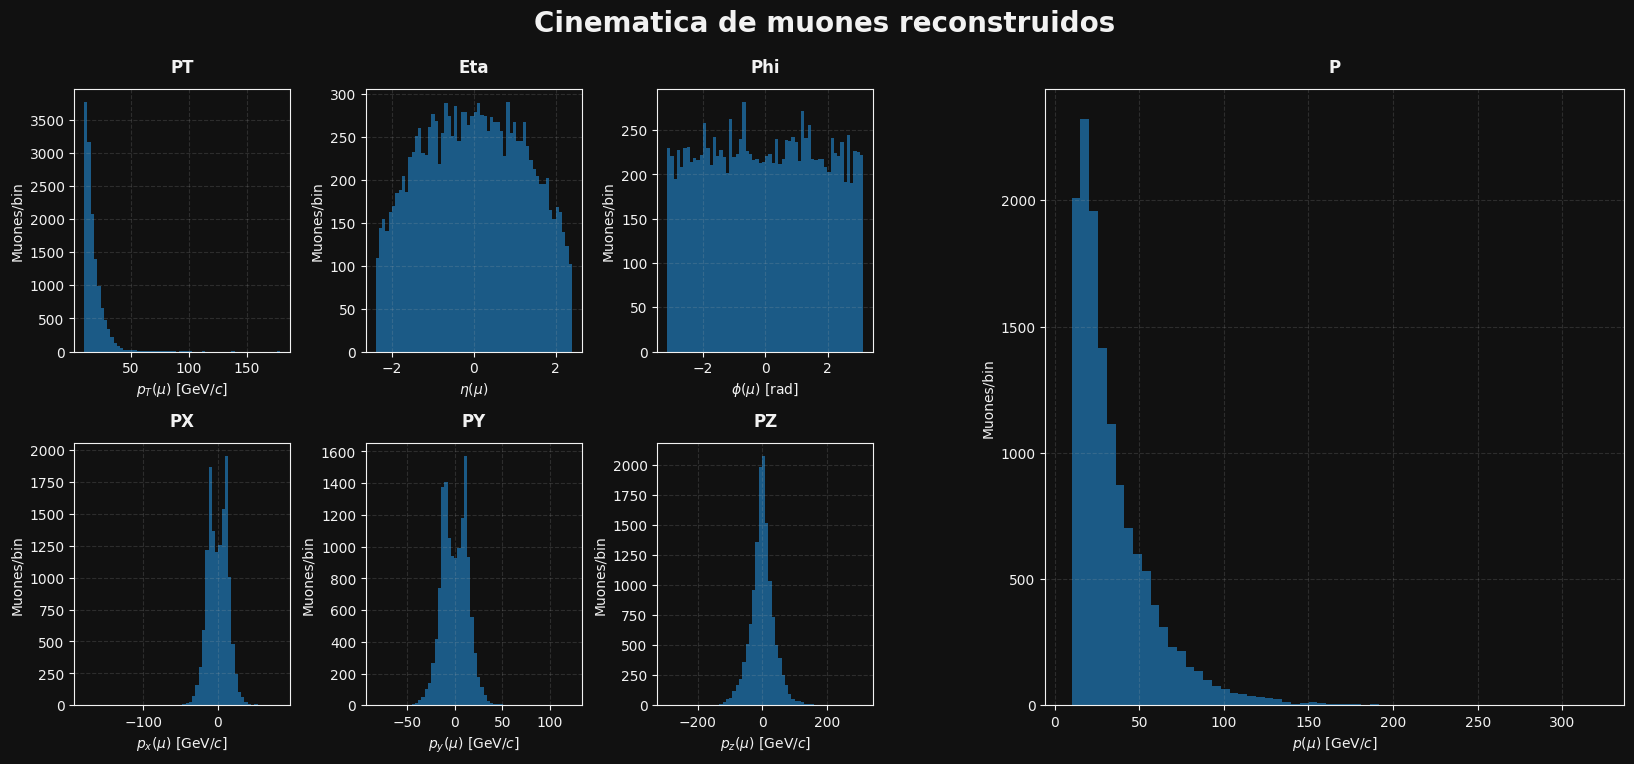

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [23]:
pt.plot_muon_kinematics(df_muons, bins=60, save=True, filename="muon_kinematics_01")

c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c01\muon_kinematics_02.png.


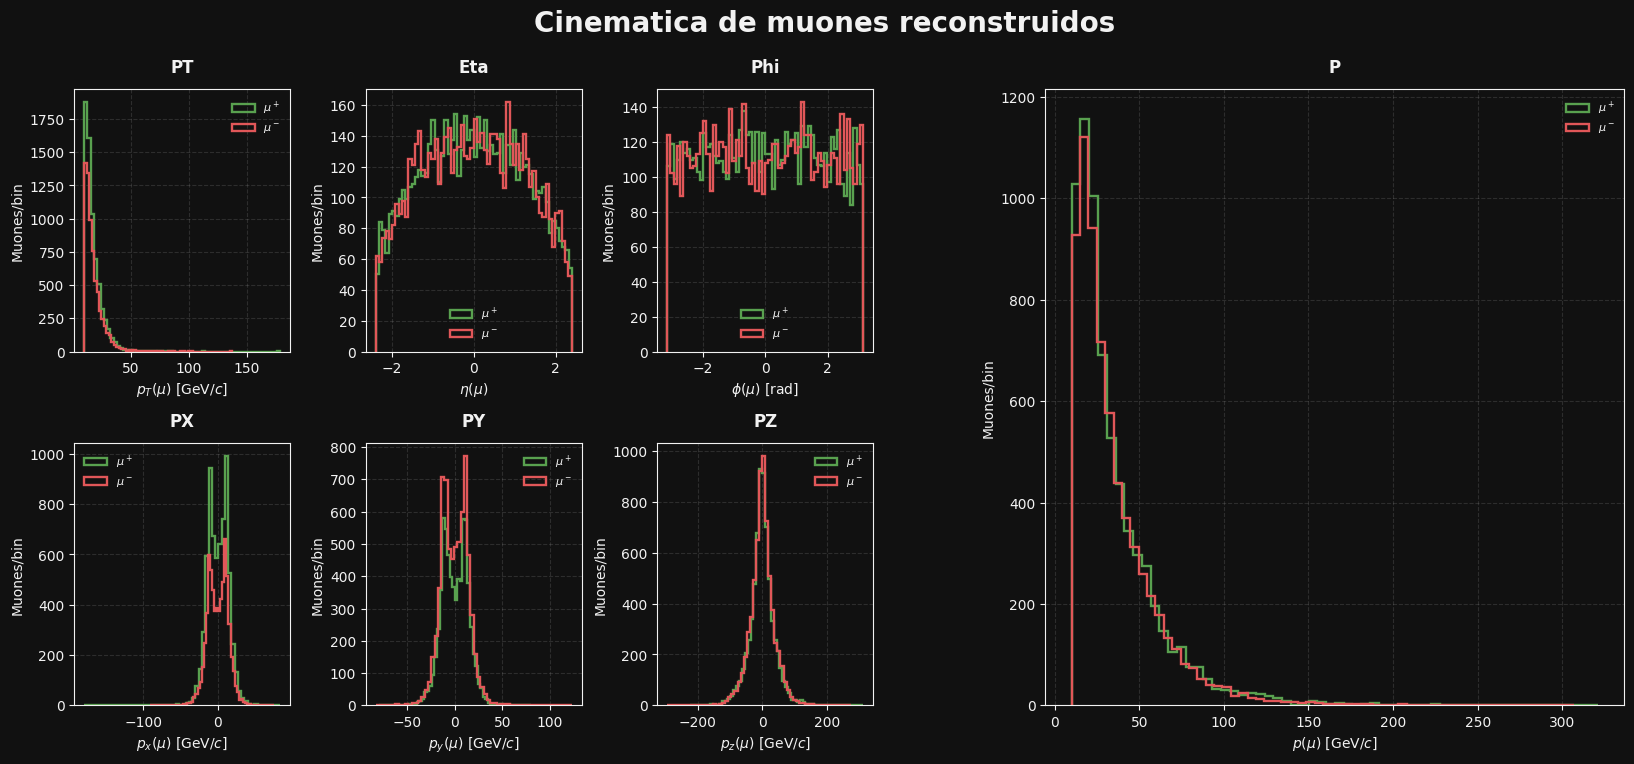

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [24]:
pt.plot_muon_kinematics(df_muons, bins=60, split_charge=True, save=True, filename="muon_kinematics_02")

Eventos con 2 muones: 4,558 (OS: 4,558 | SS: 0)
Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c01\two_muon_mass_01.png.


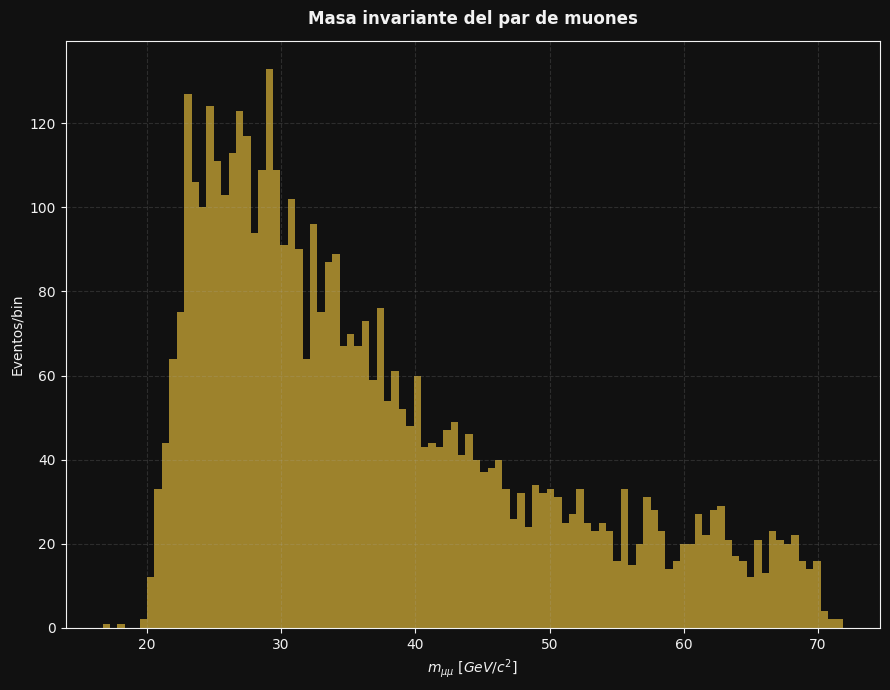

(<Figure size 900x700 with 1 Axes>,
 array([[<Axes: title={'center': 'Masa invariante del par de muones'}, xlabel='$m_{\\mu\\mu}$ [$GeV/c^2$]', ylabel='Eventos/bin'>]],
       dtype=object))

In [25]:
pares = ph.build_two_muon_system(df_muons, require_two=True)
pt.plot_two_muon_mass(pares, bins=100, save=True, filename="two_muon_mass_01")

In [26]:
df_jets = io.load_dataframe(
    branches=None,
    dataset=dset,
    tree_path='Jets'
)
df_jets.head(7)

Archivo: mpmm_10k_70_pandas.root
Árbol seleccionado: Jets
Total de eventos: 2,835 eventos


,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Mass,...,ExclYmerge45,ExclYmerge56,Constituents_fName_nbytes,Constituents_fSize,Particles_fName_nbytes,Particles_fSize,Area_fP_fX,Area_fP_fY,Area_fP_fZ,Area_fE
0,0,4,4,0,0,24.146900,1.621603,0.255182,1.036423e-08,6.625208,...,0.0,0.0,0,9,0,8,0.0,0.0,0.0,0.0
1,0,5,5,0,0,30.289186,2.829787,0.311398,1.007386e-08,4.669699,...,0.0,0.0,0,6,0,9,0.0,0.0,0.0,0.0
2,0,8,8,0,0,29.682758,-1.392784,1.812918,9.302434e-09,8.752455,...,0.0,0.0,0,7,0,6,0.0,0.0,0.0,0.0
3,0,15,15,0,0,23.648052,-0.828805,2.053122,6.148521e-09,3.993867,...,0.0,0.0,0,3,0,3,0.0,0.0,0.0,0.0
4,0,19,19,0,0,59.470032,1.432898,2.213250,9.712773e-09,10.494460,...,0.0,0.0,0,15,0,15,0.0,0.0,0.0,0.0
5,0,23,23,0,0,28.964828,-1.489973,-1.269619,9.915309e-09,9.532593,...,0.0,0.0,0,7,0,7,0.0,0.0,0.0,0.0
6,0,25,25,0,0,22.599998,1.971690,-1.055573,1.041879e-08,4.441758,...,0.0,0.0,0,9,0,9,0.0,0.0,0.0,0.0


In [27]:
particle_branches = [
    "event_id",
    "object_index",
    "root_uid",
    "PID",
    "Status",
    "PT",
    "Eta",
    "Phi",
    "Mass",
    "M1",
    "M2",
    "D1",
    "D2",
]
df_particles = io.load_dataframe(
    branches=particle_branches,
    dataset=dset,
    tree_path='Particles'
)
df_particles.head(7)

Archivo: mpmm_10k_70_pandas.root
Árbol seleccionado: Particles
Total de eventos: 11,681,886 eventos


,event_id,object_index,root_uid,PID,Status,PT,Eta,Phi,Mass,M1,M2,D1,D2
0,0,0,1,-2,21,0.000000,999.900024,0.000000,0.00000,214,-1,2,3
1,0,1,2,2,21,0.000000,-999.900024,0.000000,0.00000,228,-1,2,3
2,0,2,3,-13,23,14.095187,1.776809,-0.762392,0.10566,0,1,241,241
3,0,3,4,13,23,14.095187,1.050058,2.379201,0.10566,0,1,242,242
4,0,4,5,21,31,0.000000,999.900024,0.000000,0.00000,34,-1,7,8
5,0,5,6,21,31,0.000000,-999.900024,0.000000,0.00000,35,-1,7,8
6,0,6,7,21,43,2.969199,-4.323678,0.239867,0.00000,35,-1,41,41


In [28]:
df_muons = ph.calc_four_momentum(df_muons)
df_muons.head()

,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Charge,...,SumPt,D0,DZ,ErrorD0,ErrorDZ,PX,PY,PZ,P,E
0,0,0,0,0,1414,16.711992,1.126818,2.432248,7.338859e-09,-1,...,3.183526,0.0,0.0,0.0,0.0,-12.680873,10.885134,23.077256,28.492989,28.493185
1,0,0,0,1,1413,12.250988,1.785965,-0.749457,1.058565e-08,1,...,0.000000,-0.0,0.0,0.0,0.0,8.968447,-8.345878,35.513757,37.567455,37.567603
2,0,1,1,0,1611,10.459398,0.308113,-2.623570,4.512807e-09,1,...,1.736905,0.0,0.0,0.0,0.0,-9.087126,-5.179107,3.273907,10.959812,10.960321
3,0,2,2,0,2154,23.506353,-0.308431,1.912234,4.510036e-09,-1,...,1.225644,0.0,0.0,0.0,0.0,-7.870921,22.149430,-7.365592,24.633323,24.633550
4,0,3,3,0,2361,25.581783,0.457336,-1.532965,4.761557e-09,1,...,0.000000,-0.0,0.0,0.0,0.0,0.967563,-25.563479,12.111606,28.304039,28.304236


In [29]:
df_dimuons = ph.prepare_dimuon_analysis(df_muons, events=df_events)
df_dimuons.head(7)

,event_id,muplus_index,muplus_root_uid,muplus_pt,muplus_eta,muplus_phi,muplus_t,muplus_charge,muplus_particle_ref,muplus_isolation,...,dimuon_charge,dimuon_mass2,muon_sum_pt,pt_balance,acoplanarity,dimuon_rapidity,cos_theta_star,muplus_d0_significance,muminus_d0_significance,displacement_category
0,0,1,1413,12.250988,1.785965,-0.749457,1.058565e-08,1,242,0.0,...,0,910.891001,28.962980,0.154024,0.040112,1.407330,-0.318137,NaN,NaN,mixed
1,6,0,1618,16.926083,-1.131551,-0.775098,7.367003e-09,1,387,0.0,...,0,1411.137919,33.399971,0.013539,0.203666,-1.628578,-0.464737,NaN,NaN,mixed
2,7,1,637,14.313550,-0.750094,-0.047081,5.573970e-09,1,147,0.0,...,0,1124.990545,30.620953,0.065114,0.657269,-0.187790,0.485880,NaN,NaN,mixed
3,9,1,1707,20.133036,-0.786080,-1.457729,5.703517e-09,1,381,0.0,...,0,1717.430343,41.429031,0.028071,0.039002,-0.829238,-0.041964,NaN,NaN,mixed
4,11,1,563,10.623287,0.035266,1.801902,4.309359e-09,1,95,0.0,...,0,648.470939,22.752481,0.066186,0.132422,-0.487094,-0.455953,NaN,NaN,mixed
5,12,1,1528,11.636947,1.274993,1.797333,8.306361e-09,1,408,0.0,...,0,805.873336,28.788567,0.191558,0.064863,1.153770,-0.101421,NaN,NaN,mixed
6,13,1,1499,11.135179,1.724183,2.326961,1.066427e-08,1,400,0.0,...,0,748.934253,26.184498,0.149483,0.306492,1.305029,-0.351022,NaN,NaN,mixed


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c01\dimuon_mass_01.png.


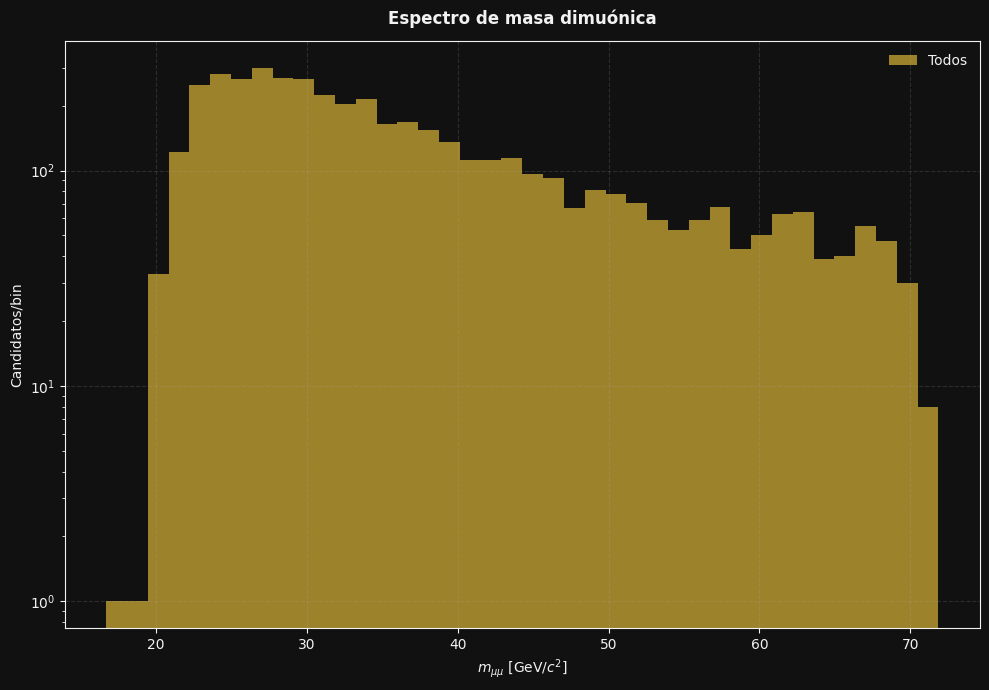

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Espectro de masa dimuónica'}, xlabel='$m_{\\mu\\mu}$ [GeV/$c^2$]', ylabel='Candidatos/bin'>)

In [34]:
pt.plot_dimuon_mass(df_dimuons, bins=40, save=True, log_y=True, filename="dimuon_mass_01")